# 🍔 Food Delivery Time Prediction
## All Models: Linear Regression | Decision Tree | Random Forest | XGBoost
---

## ⚙️ Install Dependencies

In [7]:
!pip install xgboost --quiet

%pip install xgboost --quiet


Note: you may need to restart the kernel to use updated packages.


## 📦 Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded!')


✅ Libraries loaded!


## 1. Load Data

In [41]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(train.shape, test.shape)
train.head()


(45593, 20) (11399, 19)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## 2. Preprocessing & Feature Engineering

In [42]:
# Fix target column: '(min) 24' → 24
train['Time_taken(min)'] = train['Time_taken(min)'].str.extract(r'(\d+)').astype(float)


In [43]:
# Strip whitespace
for col in train.select_dtypes('object').columns:
    train[col] = train[col].str.strip()
for col in test.select_dtypes('object').columns:
    test[col] = test[col].str.strip()


In [44]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

train['distance_km'] = train.apply(lambda x: haversine(
    x['Restaurant_latitude'], x['Restaurant_longitude'],
    x['Delivery_location_latitude'], x['Delivery_location_longitude']), axis=1)

test['distance_km'] = test.apply(lambda x: haversine(
    x['Restaurant_latitude'], x['Restaurant_longitude'],
    x['Delivery_location_latitude'], x['Delivery_location_longitude']), axis=1)


In [45]:
# Fix numeric columns (some have 'NaN' as string)
for df in [train, test]:
    df['order_hour']              = pd.to_datetime(df['Time_Orderd'], format='%H:%M', errors='coerce').dt.hour.fillna(12)
    df['Delivery_person_Age']     = pd.to_numeric(df['Delivery_person_Age'],     errors='coerce').fillna(30)
    df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce').fillna(4.5)
    df['multiple_deliveries']     = pd.to_numeric(df['multiple_deliveries'],     errors='coerce').fillna(0).astype(int)

# Encode categorical columns
cat_cols = ['Weatherconditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City']
le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print('✅ Preprocessing done!')
print('NaN check:', train.isnull().sum().sum())


✅ Preprocessing done!
NaN check: 0


## 3. Features & Train/Validation Split

In [46]:
FEATURES = [
    'Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km',
    'order_hour', 'Vehicle_condition', 'multiple_deliveries',
    'Weatherconditions', 'Road_traffic_density', 'Type_of_order',
    'Type_of_vehicle', 'Festival', 'City'
]

X = train[FEATURES]
y = train['Time_taken(min)']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train:', X_train.shape, '| X_val:', X_val.shape)


X_train: (36474, 12) | X_val: (9119, 12)


## 📊 Graph 1: Delivery Time Distribution

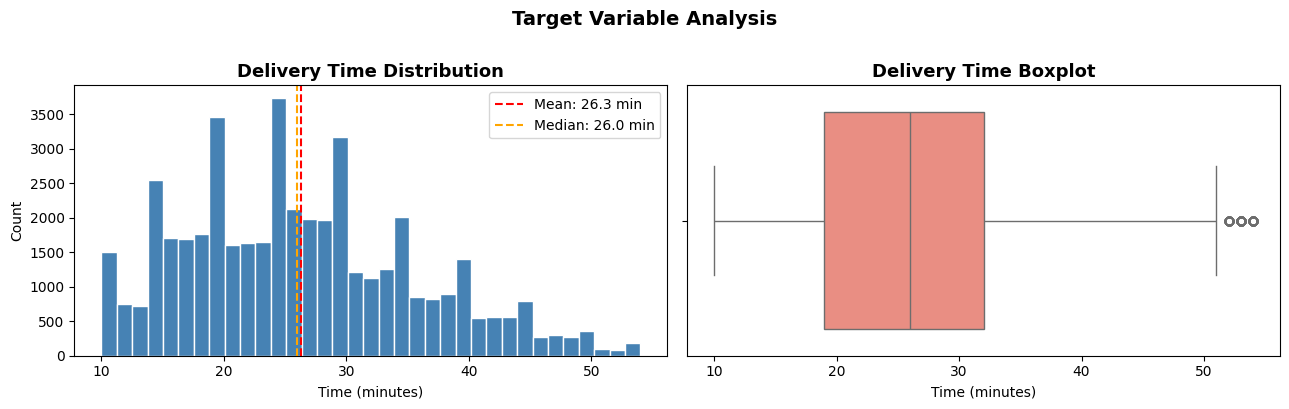

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train['Time_taken(min)'], bins=35, color='steelblue', edgecolor='white')
axes[0].axvline(train['Time_taken(min)'].mean(),   color='red',    linestyle='--', label=f'Mean: {train["Time_taken(min)"].mean():.1f} min')
axes[0].axvline(train['Time_taken(min)'].median(), color='orange', linestyle='--', label=f'Median: {train["Time_taken(min)"].median():.1f} min')
axes[0].set_title('Delivery Time Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Count') 
axes[0].legend()

sns.boxplot(x=train['Time_taken(min)'], ax=axes[1], color='salmon')
axes[1].set_title('Delivery Time Boxplot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time (minutes)')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 📊 Graph 2: Distance & Traffic vs Delivery Time

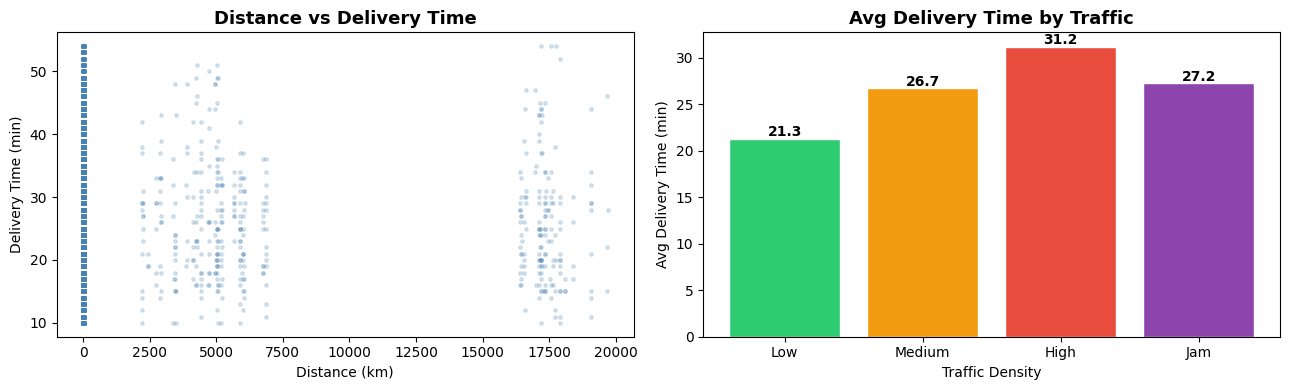

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distance vs delivery time
axes[0].scatter(train['distance_km'], train['Time_taken(min)'],
                alpha=0.2, s=6, color='steelblue')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Delivery Time (min)')
axes[0].set_title('Distance vs Delivery Time', fontsize=13, fontweight='bold')

# Avg delivery time by traffic density
traffic_map = {0:'Jam', 1:'High', 2:'Low', 3:'Medium', 4:'NaN'}
traffic_avg = train.groupby('Road_traffic_density')['Time_taken(min)'].mean()
traffic_avg.index = [traffic_map.get(i, str(i)) for i in traffic_avg.index]
traffic_avg = traffic_avg[['Low','Medium','High','Jam']]
colors = ['#2ecc71','#f39c12','#e74c3c','#8e44ad']
axes[1].bar(traffic_avg.index, traffic_avg.values, color=colors, edgecolor='white')
axes[1].set_xlabel('Traffic Density')
axes[1].set_ylabel('Avg Delivery Time (min)')
axes[1].set_title('Avg Delivery Time by Traffic', fontsize=13, fontweight='bold')
for i, v in enumerate(traffic_avg.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🔵 Model 1: Linear Regression

In [49]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

model_lr = LinearRegression()
model_lr.fit(X_train_sc, y_train)
y_pred_lr = model_lr.predict(X_val_sc)

print(f'MAE  : {mean_absolute_error(y_val, y_pred_lr):.2f} min')
print(f'RMSE : {np.sqrt(mean_squared_error(y_val, y_pred_lr)):.2f} min')
print(f'R²   : {r2_score(y_val, y_pred_lr):.4f}')


MAE  : 5.63 min
RMSE : 7.05 min
R²   : 0.4333


In [50]:
X_test_sc = scaler.transform(test[FEATURES])
preds_lr  = model_lr.predict(X_test_sc)
pd.DataFrame({'ID': test['ID'], 'Time_taken(min)': np.round(preds_lr, 1)}).to_csv('submission_lr.csv', index=False)
print('✅ submission_lr.csv saved!')


✅ submission_lr.csv saved!


---
## 🟢 Model 2: Decision Tree

In [51]:
model_dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_val)

print(f'MAE  : {mean_absolute_error(y_val, y_pred_dt):.2f} min')
print(f'RMSE : {np.sqrt(mean_squared_error(y_val, y_pred_dt)):.2f} min')
print(f'R²   : {r2_score(y_val, y_pred_dt):.4f}')


MAE  : 3.46 min
RMSE : 4.38 min
R²   : 0.7811


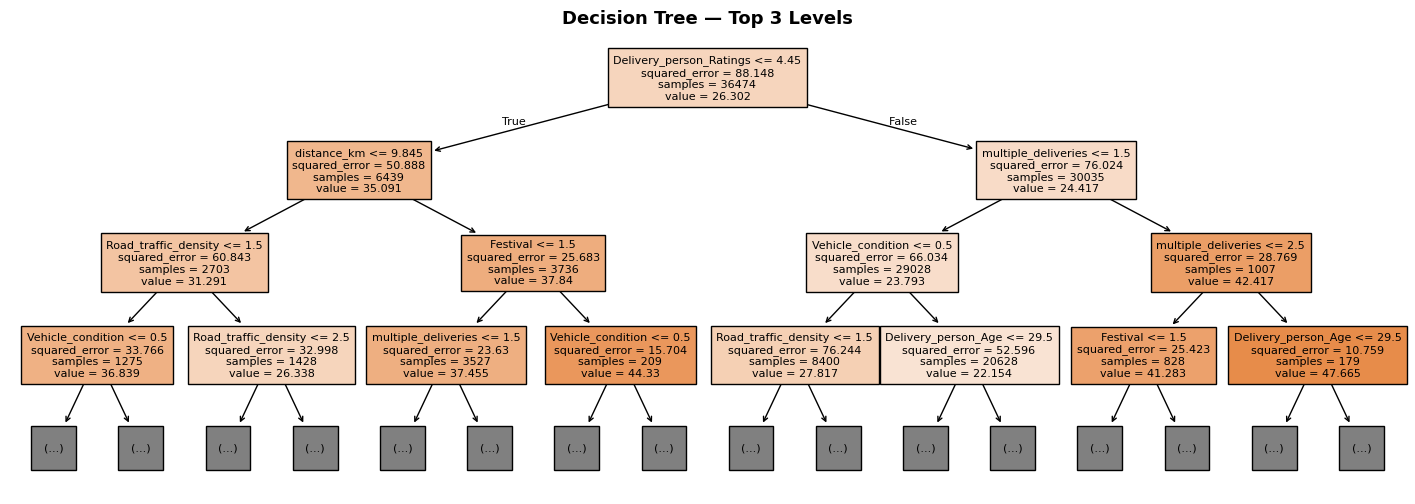

In [52]:
# Decision Tree structure (top 3 levels)
plt.figure(figsize=(18, 6))
plot_tree(model_dt, feature_names=FEATURES, max_depth=3, filled=True, fontsize=8)
plt.title('Decision Tree — Top 3 Levels', fontsize=13, fontweight='bold')
plt.show()


In [53]:
preds_dt = model_dt.predict(test[FEATURES])
pd.DataFrame({'ID': test['ID'], 'Time_taken(min)': np.round(preds_dt, 1)}).to_csv('submission_dt.csv', index=False)
print('✅ submission_dt.csv saved!')


✅ submission_dt.csv saved!


---
## 🟠 Model 3: Random Forest

In [54]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_val)

print('MAE:', round(mean_absolute_error(y_val, y_pred_rf), 2))
print('R2 Score:', round(r2_score(y_val, y_pred_rf), 4))
print(f'RMSE : {np.sqrt(mean_squared_error(y_val, y_pred_rf)):.2f} min')


MAE: 3.21
R2 Score: 0.8124
RMSE : 4.06 min


In [55]:
preds_rf = model_rf.predict(test[FEATURES])
pd.DataFrame({'ID': test['ID'], 'Time_taken(min)': np.round(preds_rf, 1)}).to_csv('submission_rf.csv', index=False)
print('✅ submission_rf.csv saved')


✅ submission_rf.csv saved


---
## 🔴 Model 4: XGBoost

In [56]:
X_train_xgb = X_train.copy()
X_val_xgb   = X_val.copy()
X_test_xgb  = test[FEATURES].copy()

model_xgb = XGBRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0
)
model_xgb.fit(X_train_xgb, y_train, eval_set=[(X_val_xgb, y_val)], verbose=False)
y_pred_xgb = model_xgb.predict(X_val_xgb)

print(f'MAE  : {mean_absolute_error(y_val, y_pred_xgb):.2f} min')
print(f'RMSE : {np.sqrt(mean_squared_error(y_val, y_pred_xgb)):.2f} min')
print(f'R\u00B2   : {r2_score(y_val, y_pred_xgb):.4f}')


MAE  : 3.17 min
RMSE : 3.98 min
R²   : 0.8195


In [57]:
preds_xgb = model_xgb.predict(X_test_xgb)
pd.DataFrame({'ID': test['ID'], 'Time_taken(min)': np.round(preds_xgb, 1)}).to_csv('submission_xgb.csv', index=False)
print('\u2705 submission_xgb.csv saved!')


✅ submission_xgb.csv saved!


---
## 📊 Graph 3: Feature Importance (Random Forest)

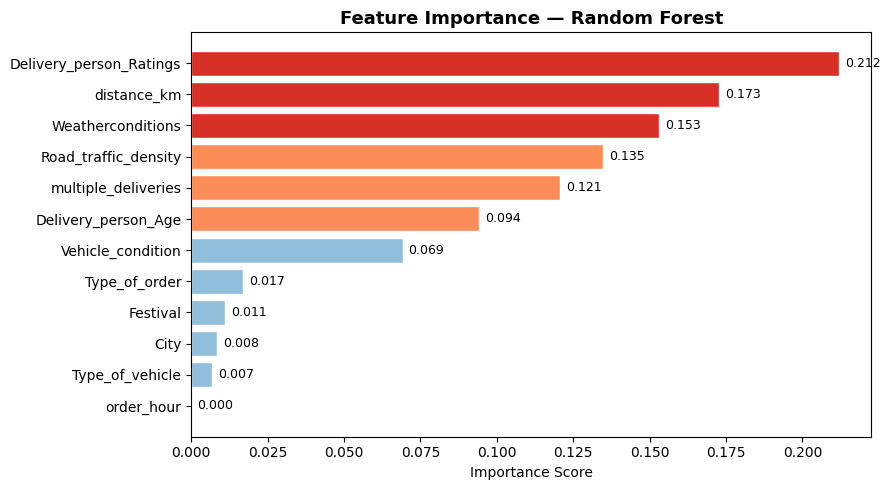

In [58]:
fi = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values()

colors = ['#d73027' if v > 0.15 else '#fc8d59' if v > 0.08 else '#91bfdb' for v in fi.values]

plt.figure(figsize=(9, 5))
bars = plt.barh(fi.index, fi.values, color=colors, edgecolor='white')
for bar, val in zip(bars, fi.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 📊 Graph 4: Actual vs Predicted — Best Model (XGBoost)

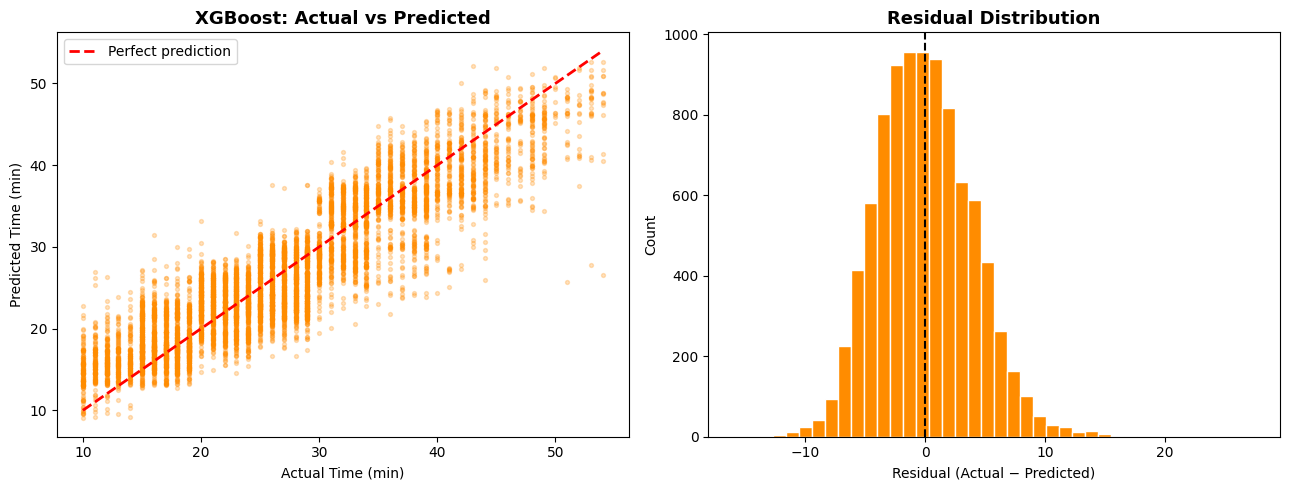

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_val, y_pred_xgb, alpha=0.25, s=8, color='darkorange')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Time (min)')
axes[0].set_ylabel('Predicted Time (min)')
axes[0].set_title('XGBoost: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals histogram
residuals = y_val - y_pred_xgb
axes[1].hist(residuals, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 📊 Graph 5: Model Comparison

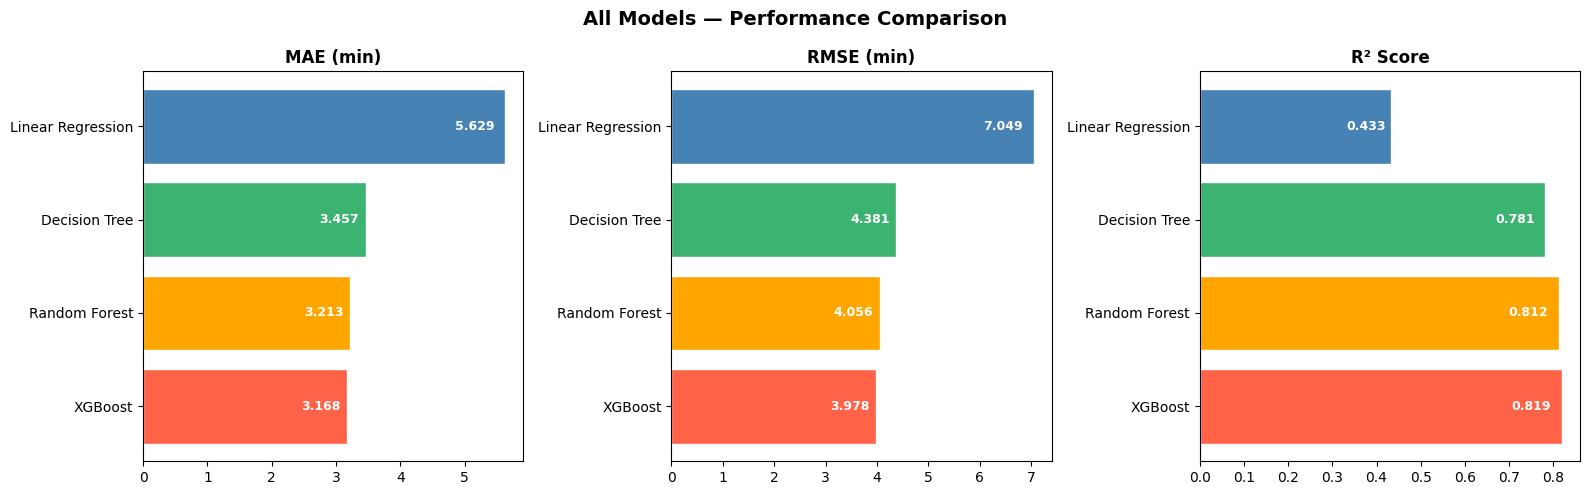


🏆 Final Results:
            Model   MAE  RMSE     R2
          XGBoost 3.168 3.978 0.8195
    Random Forest 3.213 4.056 0.8124
    Decision Tree 3.457 4.381 0.7811
Linear Regression 5.629 7.049 0.4333


In [60]:
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
preds_all   = [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_xgb]
bar_colors  = ['steelblue', 'mediumseagreen', 'orange', 'tomato']

mae_scores  = [mean_absolute_error(y_val, p)             for p in preds_all]
rmse_scores = [np.sqrt(mean_squared_error(y_val, p))     for p in preds_all]
r2_scores   = [r2_score(y_val, p)                        for p in preds_all]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, scores, metric, asc in zip(
        axes,
        [mae_scores, rmse_scores, r2_scores],
        ['MAE (min)', 'RMSE (min)', 'R² Score'],
        [True, True, False]):
    order = sorted(range(4), key=lambda i: scores[i], reverse=not asc)
    names  = [model_names[i]  for i in order]
    vals   = [scores[i]       for i in order]
    cols   = [bar_colors[i]   for i in order]
    bars   = ax.barh(names, vals, color=cols, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(v * 0.97, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha='right',
                color='white', fontweight='bold', fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')

plt.suptitle('All Models — Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model': model_names,
    'MAE':  [round(s, 3) for s in mae_scores],
    'RMSE': [round(s, 3) for s in rmse_scores],
    'R2':   [round(s, 4) for s in r2_scores]
}).sort_values('R2', ascending=False).reset_index(drop=True)

print('\n🏆 Final Results:')
print(summary.to_string(index=False))
